# Canopy Height Map in Dak Lak (Viet Nam) based on GEDI, Sentinel-1 and Sentinel-2 data with Convolutional Neural Network Unet Architecture

In [ ]:
pip install gdown

In [ ]:
!gdown 19TewnE9ntvK1wQ7seDHeQXOrXt9iAsVk

Downloading...
From (original): https://drive.google.com/uc?id=19TewnE9ntvK1wQ7seDHeQXOrXt9iAsVk
From (redirected): https://drive.google.com/uc?id=19TewnE9ntvK1wQ7seDHeQXOrXt9iAsVk&confirm=t&uuid=a47688e9-e7fe-41b3-9154-61e08b5c3ae2
To: /content/DakLak_Full_Merged_Final_Final.tif
100% 16.4G/16.4G [05:32<00:00, 49.3MB/s]


Valid data points: 195,461
Value range: 0.89 - 104.51


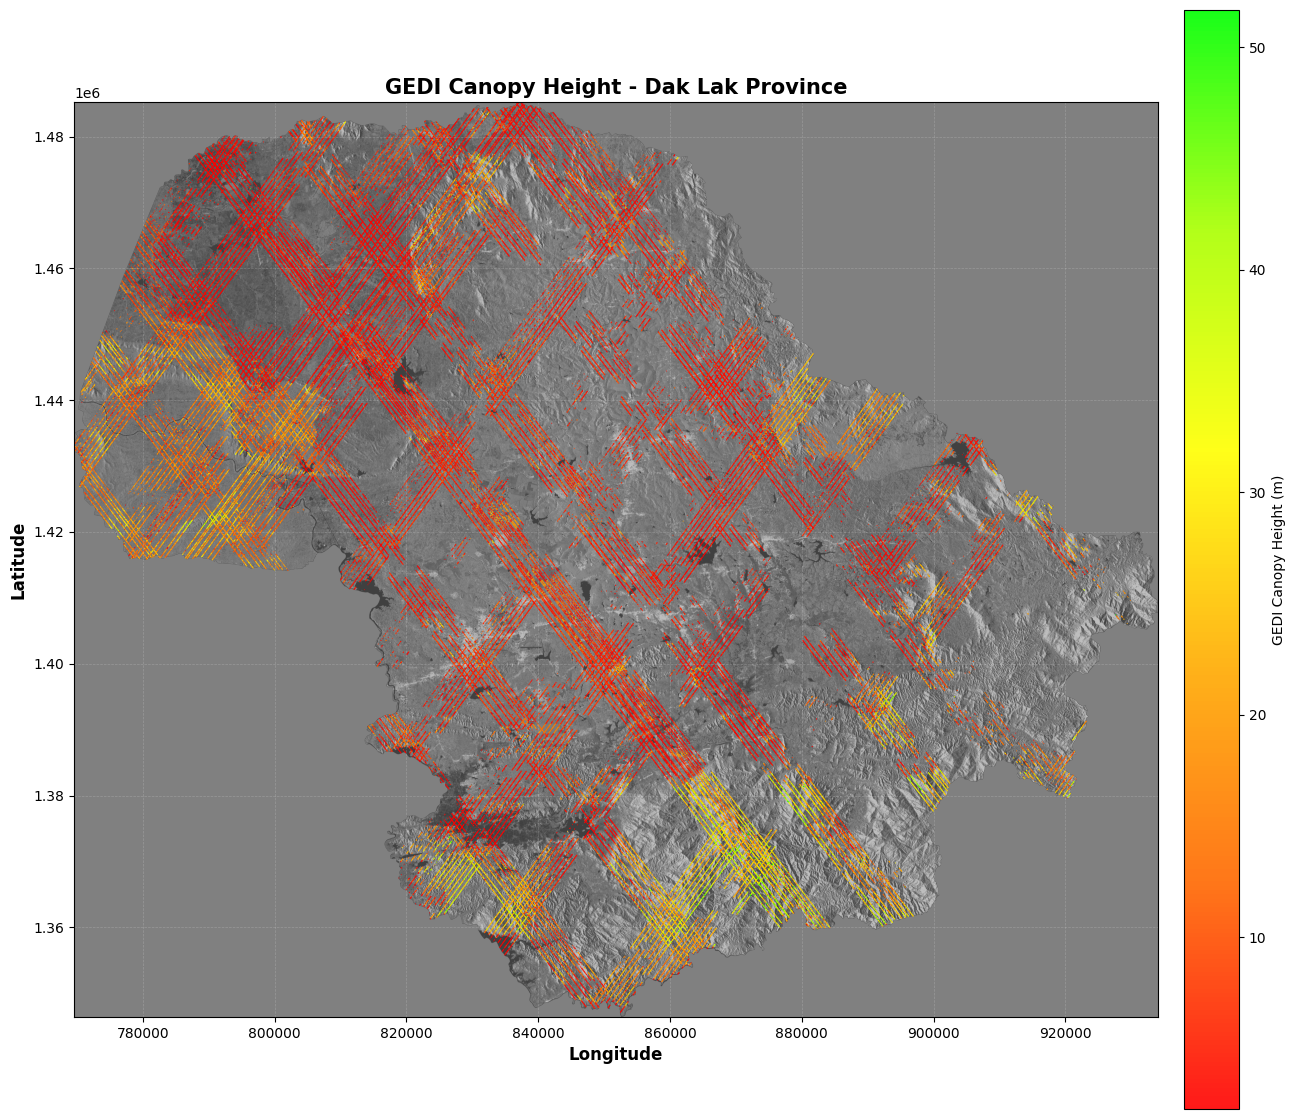

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

path = "../DakLak_Full_Merged_Final_Final.tif"

with rasterio.open(path) as src:
    canopy = src.read(1)
    basemap = src.read(2)

    # Lấy indices của pixels có dữ liệu
    valid_mask = (~np.isnan(canopy)) & (canopy > 0)
    rows, cols = np.where(valid_mask)

    # Chuyển đổi sang tọa độ địa lý
    xs, ys = rasterio.transform.xy(src.transform, rows, cols)
    values = canopy[rows, cols]

    print(f"Valid data points: {len(values):,}")
    print(f"Value range: {values.min():.2f} - {values.max():.2f}")

    # Basemap for background
    basemap_masked = np.where(np.isnan(basemap), np.nan, basemap)
    p2, p98 = np.nanpercentile(basemap_masked, [2, 98])
    basemap_norm = np.clip((basemap_masked - p2) / (p98 - p2), 0, 1)
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

# Color scheme
colors = ['#FF0000', '#FF6600', '#FFAA00', '#FFFF00', '#AAFF00', '#00FF00']
cmap = LinearSegmentedColormap.from_list('gedi', colors)

# Plot
fig, ax = plt.subplots(figsize=(14, 16))

# Background
ax.imshow(basemap_norm, cmap='gray', extent=extent, alpha=0.5)

# Scatter plot GEDI points
scatter = ax.scatter(xs, ys, c=values, cmap=cmap,
                     s=0.5, vmin=2.27, vmax=51.67,
                     edgecolors='none', alpha=0.9,
                     rasterized=True)  # rasterized=True để render nhanh hơn

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='GEDI Canopy Height (m)',
                    shrink=0.7, pad=0.02)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('GEDI Canopy Height - Dak Lak Province',
             fontsize=15, fontweight='bold')

ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, color='white')
ax.set_facecolor('#808080')

plt.tight_layout()
plt.show()

### CONFIG

In [ ]:
import os
import random
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


class Config:
    TIFF_PATH = "/content/DakLak_Full_Merged_Final_Final.tif"
    MODEL_SAVE_PATH = "unetpp_best_model_14band.pth"

    # Data Params
    TILE_SIZE = 512
    PATCH_SIZE = 256

    # Model Config
    IN_CHANNELS = 14
    OUT_CHANNELS = 1
    NB_FILTERS = [32,64, 128, 256, 512]

    # Training Config
    BATCH_SIZE = 16
    LR = 2e-4
    EPOCHS = 80
    PATCHES_PER_EPOCH = 2400
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print(f"Running on device: {Config.DEVICE}")

Running on device: cuda


### DATA PREPROCESSING

#### PROCESS OUTLIER

In [ ]:
with rasterio.open(Config.TIFF_PATH) as src:
    mosaic = src.read()
    mosaic_meta = src.meta
print(f"Mosaic shape: {mosaic.shape}") # (bands, height, width)

# 2. Xử lý Outlier cho Band 0 (GEDI)
# Tính toán ngưỡng dựa trên phân vị 0.1% và 99.9%
print("Đang tính toán ngưỡng outlier...")
low_q = np.nanpercentile(mosaic[0], 0.1)
high_q = np.nanpercentile(mosaic[0], 99.9)

print(f"Low threshold: {low_q}")
print(f"High threshold: {high_q}")

# Làm sạch band 0
band0 = mosaic[0].astype(float)
cleaned_band0 = np.where((band0 < low_q) | (band0 > high_q), np.nan, band0)
mosaic[0] = cleaned_band0


Mosaic shape: (15, 13879, 16445)
Đang tính toán ngưỡng outlier...
Low threshold: 1.8300000429153442
High threshold: 51.675399244795


####Spatial Tiling

In [ ]:
def tile_mosaic(mosaic, tile_size, check_band=1):
    bands, height, width = mosaic.shape
    tiles = []
    coords = []

    for i in range(0, height, tile_size):
        for j in range(0, width, tile_size):
            # Đảm bảo không vượt quá kích thước ảnh
            if i + tile_size > height or j + tile_size > width:
                continue

            tile = mosaic[:, i:i+tile_size, j:j+tile_size]
            # Kiểm tra NaN ở check_band
            if not np.isnan(tile[check_band]).any():
                tiles.append(tile)
                coords.append((i, j))

    return tiles, coords



In [ ]:
# Cắt tiles
tiles, coords = tile_mosaic(mosaic, Config.TILE_SIZE, check_band=1)
print("Tiles hợp lệ:", len(tiles))


Tiles hợp lệ: 431


####Target-based Filtering

In [ ]:
# Lọc tiles có chứa dữ liệu GEDI
has_gedi = np.array([np.any(~np.isnan(tile[0])) for tile in tiles])
tiles_with_gedi = [tile for tile, gedi in zip(tiles, has_gedi) if gedi]

####Dataset Splitting

In [ ]:
# Chia Train / Val / Test (80% / 10% / 10%)
# Tách Train (80%) và Temp (20%)
train_idx, temp_idx = train_test_split(
    np.arange(len(tiles_with_gedi)),
    test_size=0.2,
    random_state=42
)

# Tách Temp thành Val (10%) và Test (10%)
validation_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

tiles_train = [tiles_with_gedi[i] for i in train_idx]
tiles_validation = [tiles_with_gedi[i] for i in validation_idx]
tiles_test = [tiles_with_gedi[i] for i in test_idx]

print(f"Total tiles with GEDI: {len(tiles_with_gedi)}")
print(f"Training tiles: {len(tiles_train)}")
print(f"Validation tiles: {len(tiles_validation)}")
print(f"Testing tiles: {len(tiles_test)}")

Total tiles with GEDI: 411
Training tiles: 328
Validation tiles: 41
Testing tiles: 42


#### Patch Extraction and GEDI-based Filtering for Validation and Test Sets


In [ ]:
# Hàm cắt patch và lọc nan
def process_patches(tiles, patch_size, name="Dataset"):
    all_patches = []
    for tile in tiles:
        C, H, W = tile.shape
        for i in range(0, H, patch_size):
            for j in range(0, W, patch_size):
                patch = tile[:, i:i+patch_size, j:j+patch_size]
                all_patches.append(patch)

    # Lọc các patch mà band 0 (GEDI) toàn là nan
    valid_patches = []
    for patch in all_patches:
        if not np.all(np.isnan(patch[0])):
            valid_patches.append(patch)

    print(f"[{name}] Original patches: {len(all_patches)} | Cleaned patches: {len(valid_patches)}")
    return valid_patches


In [ ]:
# Thực hiện cắt
all_validation_patches = process_patches(tiles_validation, Config.PATCH_SIZE, name="Validation")
all_test_patches = process_patches(tiles_test, Config.PATCH_SIZE, name="Test")

[Validation] Original patches: 164 | Cleaned patches: 136
[Test] Original patches: 168 | Cleaned patches: 150


####Dataset Split Visualization

Training tiles: 328
Validation tiles: 41
Testing tiles: 42


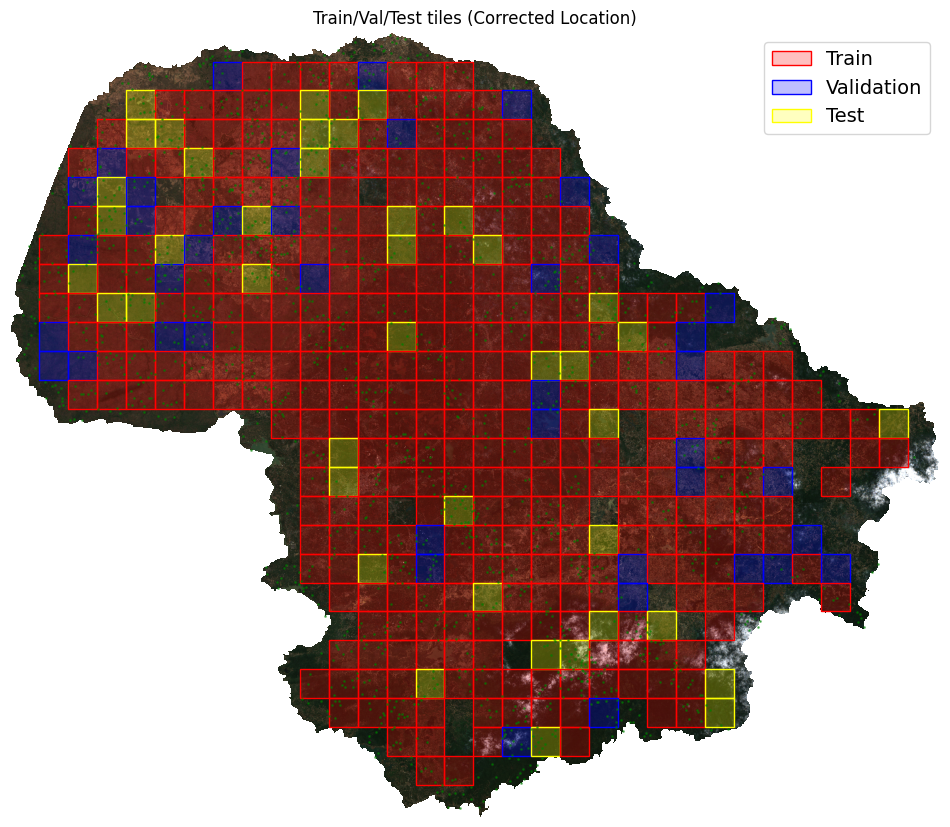

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from sklearn.model_selection import train_test_split

# Giả lập lại biến tiles từ mosaic (như code block 1 của bạn)
# tiles = tile_mosaic(mosaic, TILE_SIZE, check_band=1)

# -----------------------------------------
# 1. LOGIC SPLIT CHUẨN (FIXED)
# -----------------------------------------

# Lưu lại index gốc của từng tile
# all_indices là danh sách [0, 1, 2, ..., len(tiles)-1]
all_indices = np.arange(len(tiles))

# Kiểm tra GEDI trên từng tile
has_gedi = np.array([np.any(~np.isnan(tile[0])) for tile in tiles])

# Lấy ra các index gốc của những tile có GEDI
# Ví dụ: gedi_indices = [5, 10, 12...] (thay vì [0, 1, 2...])
valid_gedi_original_indices = all_indices[has_gedi]

# Split dựa trên danh sách index gốc này
train_indices, temp_indices = train_test_split(
    valid_gedi_original_indices, test_size=0.2, random_state=42
)
validation_indices, test_indices = train_test_split(
    temp_indices, test_size=0.5, random_state=42
)

# Tạo từ điển lookup: Original Index -> Loại Split
# Cách này đảm bảo tô màu đúng vị trí tuyệt đối trên ảnh
tile_split_map = {}
for idx in train_indices: tile_split_map[idx] = 'train'
for idx in validation_indices: tile_split_map[idx] = 'val'
for idx in test_indices: tile_split_map[idx] = 'test'

print("Training tiles:", len(train_indices))
print("Validation tiles:", len(validation_indices))
print("Testing tiles:", len(test_indices))

# -----------------------------------------
# 2. VISUALIZATION (FIXED)
# -----------------------------------------
COLOR_TRAIN = (1, 0, 0, 0.25)
COLOR_VAL   = (0, 0, 1, 0.25)
COLOR_TEST  = (1, 1, 0, 0.25)

scale = 10
# Load ảnh nền RGB (lấy band 5,6,7 như code bạn)
img_bgr = mosaic[5:8, :, :]
img_rgb = img_bgr[[2, 1, 0], :, :].transpose(1, 2, 0)
img_small = img_rgb[::scale, ::scale, :]

plt.figure(figsize=(12, 12))
plt.imshow(img_small)
plt.title("Train/Val/Test tiles (Corrected Location)")
plt.axis("off")

pixels_per_tile = Config.TILE_SIZE
height, width, _ = img_rgb.shape

# Biến đếm index gốc trùng khớp với logic tile_mosaic ban đầu
current_tile_idx = 0

for i in range(0, height, pixels_per_tile):
    for j in range(0, width, pixels_per_tile):
        # Kiểm tra biên (phải giống hệt logic hàm tile_mosaic)
        if i + pixels_per_tile > height or j + pixels_per_tile > width:
            continue

        # Lấy tile để kiểm tra điều kiện y hệt hàm tile_mosaic
        # Lưu ý: Phải dùng đúng check_band=1 như lúc tạo tiles
        check_band_data = mosaic[1, i:i+pixels_per_tile, j:j+pixels_per_tile]

        # Logic check phải khớp 100% với hàm tile_mosaic
        if not np.isnan(check_band_data).any():

            # Kiểm tra xem index hiện tại thuộc tập nào
            if current_tile_idx in tile_split_map:
                split_type = tile_split_map[current_tile_idx]

                if split_type == 'train':
                    fc, ec = COLOR_TRAIN, 'red'
                elif split_type == 'val':
                    fc, ec = COLOR_VAL, 'blue'
                elif split_type == 'test':
                    fc, ec = COLOR_TEST, 'yellow'

                # Vẽ hình chữ nhật
                rect = Rectangle(
                    (j / scale, i / scale),
                    pixels_per_tile / scale,
                    pixels_per_tile / scale,
                    linewidth=1, edgecolor=ec, facecolor=fc
                )
                plt.gca().add_patch(rect)

            # Tăng biến đếm index (chỉ tăng khi tile hợp lệ - khớp với logic append của tile_mosaic)
            current_tile_idx += 1

# Legend & GEDI Scatter (Giữ nguyên code của bạn)
legend_patches = [
    Patch(facecolor=COLOR_TRAIN, edgecolor='red', label='Train'),
    Patch(facecolor=COLOR_VAL,   edgecolor='blue', label='Validation'),
    Patch(facecolor=COLOR_TEST,  edgecolor='yellow', label='Test')
]
# Vẽ GEDI footprint
gedi = mosaic[0]
gedi_small = gedi[::scale, ::scale]
y, x = np.where(~np.isnan(gedi_small))
plt.scatter(x, y, s=1, color='green', label='GEDI footprint', alpha=0.5)

plt.legend(handles=legend_patches, loc='upper right', fontsize=14)
plt.show()

Train GEDI pixels: 134610
Val GEDI pixels: 16802
Test GEDI pixels: 21937


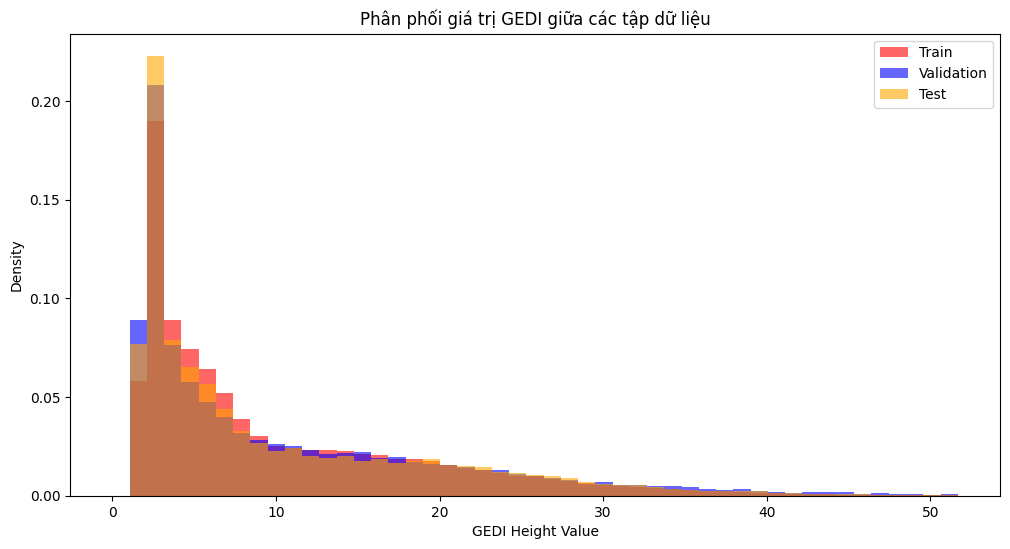

In [ ]:
# Gom dữ liệu pixel GEDI (không tính NaN)
train_values = np.concatenate([tile[0][~np.isnan(tile[0])] for tile in tiles_train])
validation_values = np.concatenate([p[0][~np.isnan(p[0])] for p in all_validation_patches])
test_values = np.concatenate([p[0][~np.isnan(p[0])] for p in all_test_patches])

print(f"Train GEDI pixels: {len(train_values)}")
print(f"Val GEDI pixels: {len(validation_values)}")
print(f"Test GEDI pixels: {len(test_values)}")

# Vẽ Histogram
bins = np.linspace(0, np.nanmax(mosaic[0]), 50)

plt.figure(figsize=(12,6))
plt.hist(train_values, bins=bins, alpha=0.6, label='Train', color='red', density=True)
plt.hist(validation_values, bins=bins, alpha=0.6, label='Validation', color='blue', density=True)
plt.hist(test_values, bins=bins, alpha=0.6, label='Test', color='orange', density=True)

plt.xlabel('GEDI Height Value')
plt.ylabel('Density')
plt.title('Phân phối giá trị GEDI giữa các tập dữ liệu')
plt.legend()
plt.show()

##Training pipeline

#### Training Dataset


In [ ]:
class TrainTileDataset(Dataset):
    def __init__(self, tiles, patch_size=256, patches_per_epoch=1000):
        self.tiles = tiles
        self.patch_size = patch_size
        self.patches_per_epoch = patches_per_epoch

        # Trọng số lấy mẫu dựa trên lượng GEDI pixel
        self.weights = np.array([np.sum(~np.isnan(tile[0])) for tile in tiles], dtype=np.float32)
        self.weights /= (self.weights.sum() + 1e-6)

    def __len__(self): return self.patches_per_epoch

    def __getitem__(self, idx):
        # Chọn Tile
        tile_idx = np.random.choice(len(self.tiles), p=self.weights)
        tile = self.tiles[tile_idx]
        C, H, W = tile.shape

        # Random Crop
        for _ in range(20):
            x = random.randint(0, W - self.patch_size)
            y = random.randint(0, H - self.patch_size)
            gedi_patch = tile[0, y:y+self.patch_size, x:x+self.patch_size]

            # Chỉ lấy nếu có dữ liệu GEDI
            if np.any(~np.isnan(gedi_patch)):
                break
        else:
            x, y = 0, 0

        img_patch = tile[1:, y:y+self.patch_size, x:x+self.patch_size]
        gedi_patch = tile[0, y:y+self.patch_size, x:x+self.patch_size]

        # Augmentation (Flip)
        if random.random() > 0.5:
            img_patch = np.flip(img_patch, axis=2)
            gedi_patch = np.flip(gedi_patch, axis=1)

        return torch.from_numpy(img_patch.copy()).float(), torch.from_numpy(gedi_patch.copy()).float().unsqueeze(0)

####TESTING DATASET

In [ ]:
class ValTestPatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches
    def __len__(self): return len(self.patches)
    def __getitem__(self, idx):
        patch = self.patches[idx]
        img = torch.from_numpy(patch[1:]).float()
        gedi = torch.from_numpy(patch[0:1]).float()
        return img, gedi



####Validation and Test DataLoader

In [ ]:
# Setup Loaders
train_ds = TrainTileDataset(tiles_train, patch_size=Config.PATCH_SIZE, patches_per_epoch=Config.PATCHES_PER_EPOCH)
val_ds   = ValTestPatchDataset(all_validation_patches)
test_ds  = ValTestPatchDataset(all_test_patches)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=8)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)

####UNET PLUS PLUS ARCHITECTURE

In [ ]:
##THAM KHẢO CODE NGUỒN https://github.com/4uiiurz1/pytorch-nested-unet/blob/master/archs.py
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

# --- UNet++ Architecture ---
class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        nb_filter = Config.NB_FILTERS
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv0_0 = ConvBlock(in_channels, nb_filter[0])
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1])
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2])
        self.conv3_0 = ConvBlock(nb_filter[2], nb_filter[3])
        self.conv4_0 = ConvBlock(nb_filter[3], nb_filter[4])

        self.conv0_1 = ConvBlock(nb_filter[0]+nb_filter[1], nb_filter[0])
        self.conv1_1 = ConvBlock(nb_filter[1]+nb_filter[2], nb_filter[1])
        self.conv2_1 = ConvBlock(nb_filter[2]+nb_filter[3], nb_filter[2])
        self.conv3_1 = ConvBlock(nb_filter[3]+nb_filter[4], nb_filter[3])

        self.conv0_2 = ConvBlock(nb_filter[0]*2+nb_filter[1], nb_filter[0])
        self.conv1_2 = ConvBlock(nb_filter[1]*2+nb_filter[2], nb_filter[1])
        self.conv2_2 = ConvBlock(nb_filter[2]*2+nb_filter[3], nb_filter[2])

        self.conv0_3 = ConvBlock(nb_filter[0]*3+nb_filter[1], nb_filter[0])
        self.conv1_3 = ConvBlock(nb_filter[1]*3+nb_filter[2], nb_filter[1])

        self.conv0_4 = ConvBlock(nb_filter[0]*4+nb_filter[1], nb_filter[0])
        self.final = nn.Conv2d(nb_filter[0], out_channels, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))

        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))

        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))

        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))
        return self.final(x0_4)



#### METRIC FN

In [ ]:
# --- Metric Helper Functions ---
def compute_global_metrics(all_preds, all_targets):
    if len(all_preds) == 0: return 0, 0, 0

    y_pred = torch.cat(all_preds)
    y_true = torch.cat(all_targets)

    # 1. MAE
    mae = torch.abs(y_pred - y_true).mean().item()

    # 2. RMSE
    mse = ((y_pred - y_true) ** 2).mean()
    rmse = torch.sqrt(mse).item()

    # 3. R2 Score
    # R2 = 1 - (SS_res / SS_tot)
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()

    if ss_tot == 0:
        r2 = 0.0
    else:
        r2 = (1 - ss_res / ss_tot).item()

    return mae, rmse, r2



####TRAINING

In [ ]:
model = UNetPlusPlus(Config.IN_CHANNELS, Config.OUT_CHANNELS).to(Config.DEVICE)
optimizer = optim.Adam(model.parameters(), lr=Config.LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3, min_lr=1e-6)
criterion = nn.L1Loss(reduction='none')


In [ ]:
def train_one_epoch(model, loader, optimizer, device, epoch, total_epochs):
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        # Thay NaN trong input
        x = torch.nan_to_num(x, nan=0.0)

        optimizer.zero_grad()
        pred = model(x)

        # Mask NaN ở target
        mask = ~torch.isnan(y)
        if mask.sum() > 0:
            loss = torch.abs(pred[mask] - y[mask]).mean()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_count += 1
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        else:
            optimizer.step()

    avg_train_mae = train_loss_sum / max(train_count, 1)
    return avg_train_mae


In [ ]:
def validate_one_epoch(model, loader, device):
    model.eval()
    val_preds_list = []
    val_targets_list = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = torch.nan_to_num(x, nan=0.0)
            pred = model(x)

            mask = ~torch.isnan(y)
            if mask.sum() > 0:
                val_preds_list.append(pred[mask].cpu())
                val_targets_list.append(y[mask].cpu())

    val_mae, val_rmse, val_r2 = compute_global_metrics(
        val_preds_list, val_targets_list
    )

    return val_mae, val_rmse, val_r2


##### Thực nghiệm 1: MODEL VỚI ĐIỀU KIỆN PATCH = 1024, TILE = 256, NB_FILTER=[32, 64, 128, 256, 512]


In [ ]:
# ======================
# INIT
# ======================
history = {
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

best_mae = float('inf')
print("Bắt đầu huấn luyện...")

# ======================
# TRAIN LOOP
# ======================
for epoch in range(Config.EPOCHS):

    # --- TRAIN ---
    avg_train_mae = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=Config.DEVICE,
        epoch=epoch,
        total_epochs=Config.EPOCHS
    )

    # --- VALIDATE ---
    val_mae, val_rmse, val_r2 = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=Config.DEVICE
    )

    # --- SAVE HISTORY ---
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    # --- LOG ---
    print(
        f"Epoch {epoch+1}/{Config.EPOCHS} | "
        f"Train MAE: {avg_train_mae:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )

    # --- SCHEDULER ---
    scheduler.step(val_mae)

    # --- CHECKPOINT ---
    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")


Bắt đầu huấn luyện...


Epoch 1/80: 100%|██████████| 300/300 [00:38<00:00,  7.88it/s, loss=12.2500]


Epoch 1/80 | Train MAE: 8.5095 | Val MAE: 8.3040 | Val RMSE: 12.5015 | Val R2: -1.2054
>>> Saved New Best Model (MAE: 8.3040)


Epoch 2/80: 100%|██████████| 300/300 [00:36<00:00,  8.31it/s, loss=5.2380]


Epoch 2/80 | Train MAE: 7.6198 | Val MAE: 7.1501 | Val RMSE: 11.1228 | Val R2: -0.7458
>>> Saved New Best Model (MAE: 7.1501)


...

Epoch 78/80 | Train MAE: 2.1268 | Val MAE: 3.3356 | Val RMSE: 5.4548 | Val R2: 0.5801


Epoch 79/80: 100%|██████████| 300/300 [00:36<00:00,  8.30it/s, loss=2.0582]


Epoch 79/80 | Train MAE: 2.1286 | Val MAE: 3.3416 | Val RMSE: 5.4752 | Val R2: 0.5770


Epoch 80/80: 100%|██████████| 300/300 [00:36<00:00,  8.27it/s, loss=1.8689]


Epoch 80/80 | Train MAE: 2.1239 | Val MAE: 3.3284 | Val RMSE: 5.4457 | Val R2: 0.5815


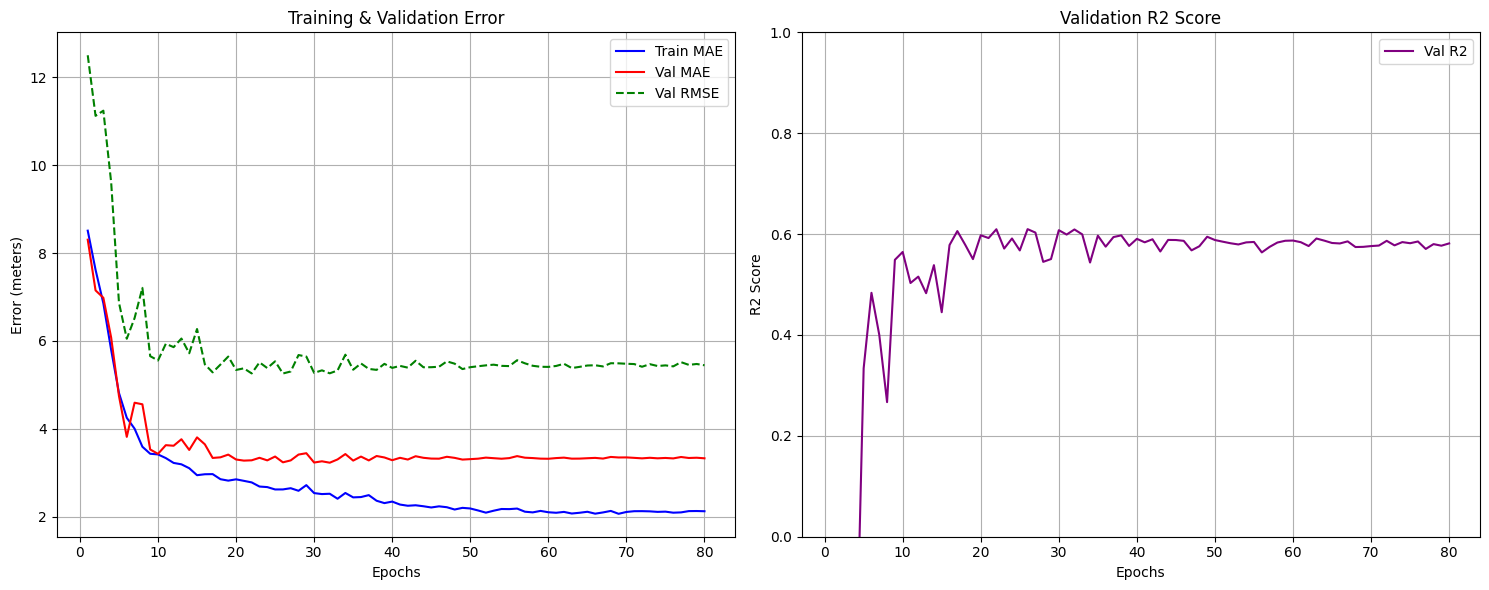

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_mae']) + 1)

    plt.figure(figsize=(15, 6))

    # Biểu đồ 1: MAE và RMSE (Sai số)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_mae'], 'b-', label='Train MAE')
    plt.plot(epochs, history['val_mae'], 'r-', label='Val MAE')
    plt.plot(epochs, history['val_rmse'], 'g--', label='Val RMSE')
    plt.title('Training & Validation Error')
    plt.xlabel('Epochs')
    plt.ylabel('Error (meters)')
    plt.legend()
    plt.grid(True)

    # Biểu đồ 2: R2 Score (Độ chính xác)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_r2'], 'purple', label='Val R2')
    plt.title('Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

#####Thực nghiệm 2: CÓ TĂNG CƯỜNG ẢNH BẰNG CÁCH LẬT, GIỮ NGUYÊN PATCH 1024 VÀ TILE 256, NB_FILTER=[32, 64, 128, 256, 512]

In [ ]:
history = {
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

best_mae = float('inf')
print("Bắt đầu huấn luyện...")

# ======================
# TRAIN LOOP
# ======================
for epoch in range(Config.EPOCHS):

    # --- TRAIN ---
    avg_train_mae = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=Config.DEVICE,
        epoch=epoch,
        total_epochs=Config.EPOCHS
    )

    # --- VALIDATE ---
    val_mae, val_rmse, val_r2 = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=Config.DEVICE
    )

    # --- SAVE HISTORY ---
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    # --- LOG ---
    print(
        f"Epoch {epoch+1}/{Config.EPOCHS} | "
        f"Train MAE: {avg_train_mae:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )

    # --- SCHEDULER ---
    scheduler.step(val_mae)

    # --- CHECKPOINT ---
    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")


Bắt đầu huấn luyện...


Epoch 1/80: 100%|██████████| 300/300 [00:36<00:00,  8.16it/s, loss=13.2085]


Epoch 1/80 | Train MAE: 8.7126 | Val MAE: 8.0910 | Val RMSE: 11.8024 | Val R2: -0.9656
>>> Saved New Best Model (MAE: 8.0910)


Epoch 2/80: 100%|██████████| 300/300 [00:36<00:00,  8.24it/s, loss=6.6971]


Epoch 2/80 | Train MAE: 7.3677 | Val MAE: 6.4507 | Val RMSE: 10.2045 | Val R2: -0.4694
>>> Saved New Best Model (MAE: 6.4507)


...

Epoch 78/80 | Train MAE: 2.4311 | Val MAE: 3.2212 | Val RMSE: 5.1919 | Val R2: 0.6196


Epoch 79/80: 100%|██████████| 300/300 [00:36<00:00,  8.16it/s, loss=2.1800]


Epoch 79/80 | Train MAE: 2.4428 | Val MAE: 3.2143 | Val RMSE: 5.1681 | Val R2: 0.6231


Epoch 80/80: 100%|██████████| 300/300 [00:36<00:00,  8.18it/s, loss=2.4790]


Epoch 80/80 | Train MAE: 2.4308 | Val MAE: 3.1942 | Val RMSE: 5.1725 | Val R2: 0.6225


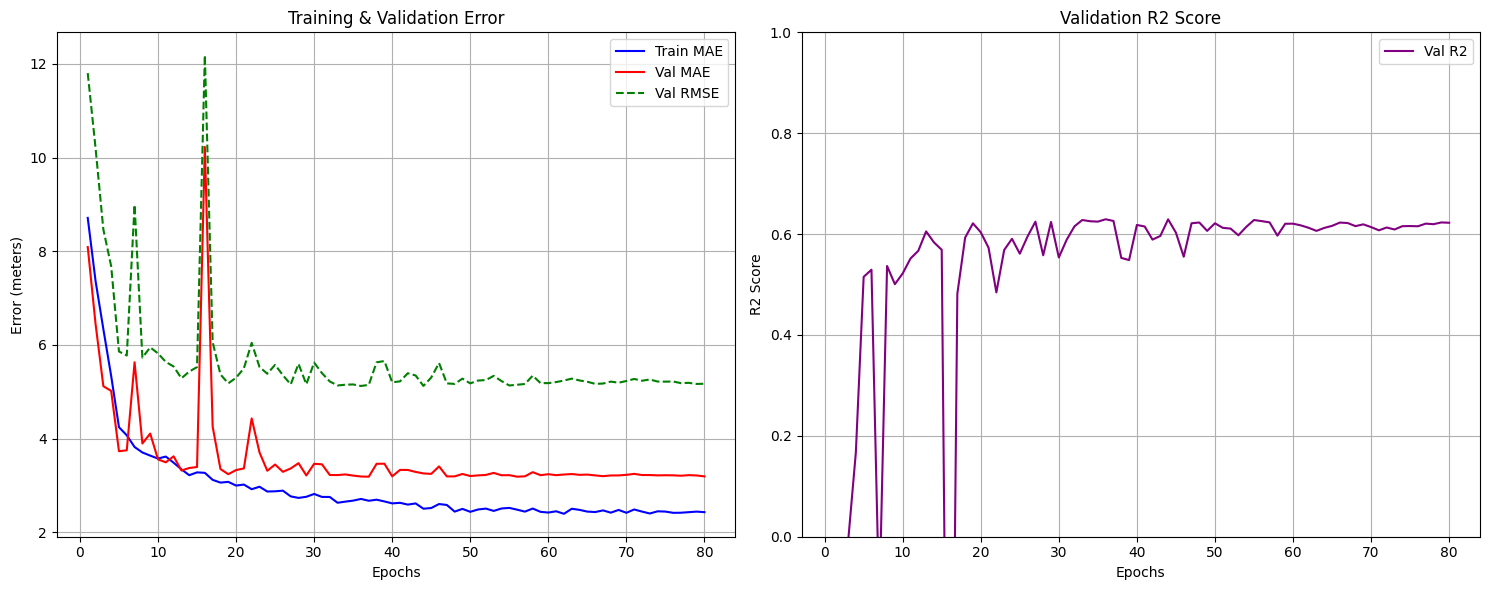

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_mae']) + 1)

    plt.figure(figsize=(15, 6))

    # Biểu đồ 1: MAE và RMSE
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_mae'], 'b-', label='Train MAE')
    plt.plot(epochs, history['val_mae'], 'r-', label='Val MAE')
    plt.plot(epochs, history['val_rmse'], 'g--', label='Val RMSE')
    plt.title('Training & Validation Error')
    plt.xlabel('Epochs')
    plt.ylabel('Error (meters)')
    plt.legend()
    plt.grid(True)

    # Biểu đồ 2: R2 Score
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_r2'], 'purple', label='Val R2')
    plt.title('Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

##### Thực nghiệm 3: BỔ SUNG VIỆC TĂNG CƯỜNG XOAY THÊM 90 180 270 PATCH 1024 TILE 256 với NB_FILTER=[32, 64, 128, 256, 512]


In [ ]:
class TrainTileDataset(Dataset):
    def __init__(self, tiles, patch_size=256, patches_per_epoch=1000):
        self.tiles = tiles
        self.patch_size = patch_size
        self.patches_per_epoch = patches_per_epoch

        self.weights = np.array([np.sum(~np.isnan(tile[0])) for tile in tiles], dtype=np.float32)
        if self.weights.sum() > 0:
            self.weights /= self.weights.sum()
        else:
            self.weights = np.ones(len(tiles)) / len(tiles)

    def __len__(self): return self.patches_per_epoch

    def __getitem__(self, idx):
        # 1. Chọn Tile ngẫu nhiên theo trọng số
        tile_idx = np.random.choice(len(self.tiles), p=self.weights)
        tile = self.tiles[tile_idx]
        C, H, W = tile.shape

        # 2. Random Crop (Cắt ngẫu nhiên)
        for _ in range(20):
            x = random.randint(0, W - self.patch_size)
            y = random.randint(0, H - self.patch_size)
            gedi_patch = tile[0, y:y+self.patch_size, x:x+self.patch_size]

            if np.any(~np.isnan(gedi_patch)):
                break
        else:
            x, y = 0, 0

        # Tách Input (Band 1->14) và Target (Band 0)
        img_patch = tile[1:, y:y+self.patch_size, x:x+self.patch_size]
        gedi_patch = tile[0, y:y+self.patch_size, x:x+self.patch_size]

        # --- 3. DATA AUGMENTATION ---

        # a. Random Horizontal Flip (Lật Ngang - Xác suất 50%)
        if random.random() > 0.5:
            img_patch = np.flip(img_patch, axis=2)
            gedi_patch = np.flip(gedi_patch, axis=1)

        # b. Random Vertical Flip (Lật Dọc - Xác suất 50%)
        if random.random() > 0.5:
            img_patch = np.flip(img_patch, axis=1)
            gedi_patch = np.flip(gedi_patch, axis=0)

        # c. Random Rotation (Xoay 90, 180, 270 độ)
        k = random.randint(0, 3)
        if k > 0:
            img_patch = np.rot90(img_patch, k, axes=(1, 2))
            gedi_patch = np.rot90(gedi_patch, k, axes=(0, 1))

        return torch.from_numpy(img_patch.copy()).float(), torch.from_numpy(gedi_patch.copy()).float().unsqueeze(0)


class ValTestPatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches
    def __len__(self): return len(self.patches)
    def __getitem__(self, idx):
        patch = self.patches[idx]
        img = torch.from_numpy(patch[1:]).float()
        gedi = torch.from_numpy(patch[0:1]).float()
        return img, gedi



In [ ]:
# --- TRAINING---
history = {
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

print("Bắt đầu huấn luyện...")
best_mae = float('inf')

for epoch in range(Config.EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0
    train_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")
    for x, y in pbar:
        x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
        x = torch.nan_to_num(x, nan=0.0)

        optimizer.zero_grad()
        pred = model(x)

        mask = ~torch.isnan(y)
        if mask.sum() > 0:
            loss = torch.abs(pred[mask] - y[mask]).mean()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_count += 1
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        else:
            optimizer.step()

    avg_train_mae = train_loss_sum / max(train_count, 1)

    # --- VALIDATE / TEST ---
    model.eval()
    val_preds_list = []
    val_targets_list = []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
            x = torch.nan_to_num(x, nan=0.0)

            pred = model(x)

            mask = ~torch.isnan(y)
            if mask.sum() > 0:
                val_preds_list.append(pred[mask].cpu())
                val_targets_list.append(y[mask].cpu())

    # Tính toán Metrics
    val_mae, val_rmse, val_r2 = compute_global_metrics(val_preds_list, val_targets_list)

    # --- 2. LƯU KẾT QUẢ VÀO HISTORY (THÊM ĐOẠN NÀY) ---
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    # --- LOGGING ---
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Train MAE: {avg_train_mae:.4f} | Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f} | Val R2: {val_r2:.4f}")

    # Scheduler & Checkpoint
    scheduler.step(val_mae)

    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")

Bắt đầu huấn luyện...


Epoch 1/80: 100%|██████████| 300/300 [00:38<00:00,  7.82it/s, loss=1.8823]


Epoch 1/80 | Train MAE: 2.6122 | Val MAE: 3.1997 | Val RMSE: 5.1469 | Val R2: 0.6262
>>> Saved New Best Model (MAE: 3.1997)


Epoch 2/80: 100%|██████████| 300/300 [00:38<00:00,  7.85it/s, loss=1.8985]


Epoch 2/80 | Train MAE: 2.6795 | Val MAE: 3.2042 | Val RMSE: 5.1511 | Val R2: 0.6256


...

Epoch 78/80 | Train MAE: 2.5968 | Val MAE: 3.1980 | Val RMSE: 5.1543 | Val R2: 0.6251


Epoch 79/80: 100%|██████████| 300/300 [00:38<00:00,  7.77it/s, loss=2.9963]


Epoch 79/80 | Train MAE: 2.5943 | Val MAE: 3.2066 | Val RMSE: 5.1739 | Val R2: 0.6223


Epoch 80/80: 100%|██████████| 300/300 [00:38<00:00,  7.82it/s, loss=3.0527]


Epoch 80/80 | Train MAE: 2.6077 | Val MAE: 3.1828 | Val RMSE: 5.1227 | Val R2: 0.6297


#####Thực nghiệm 4: GIỮ NGUYÊN NB_FILTER=[32, 64, 128, 256, 512], GIẢM PATH CÒN 512 VÀ GIỮ NGUYÊN TILE 256, có tăng cường ảnh

In [ ]:
# ======================
# INIT
# ======================
history = {
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

best_mae = float('inf')
print("Bắt đầu huấn luyện...")

# ======================
# TRAIN LOOP
# ======================
for epoch in range(Config.EPOCHS):

    # --- TRAIN ---
    avg_train_mae = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=Config.DEVICE,
        epoch=epoch,
        total_epochs=Config.EPOCHS
    )

    # --- VALIDATE ---
    val_mae, val_rmse, val_r2 = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=Config.DEVICE
    )

    # --- SAVE HISTORY ---
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    # --- LOG ---
    print(
        f"Epoch {epoch+1}/{Config.EPOCHS} | "
        f"Train MAE: {avg_train_mae:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )

    # --- SCHEDULER ---
    scheduler.step(val_mae)

    # --- CHECKPOINT ---
    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")

Bắt đầu huấn luyện...


Epoch 1/80: 100%|██████████| 300/300 [00:45<00:00,  6.61it/s, loss=10.2193]


Epoch 1/80 | Train MAE: 9.6041 | Val MAE: 9.3991 | Val RMSE: 13.4494 | Val R2: -0.8576
>>> Saved New Best Model (MAE: 9.3991)


Epoch 2/80: 100%|██████████| 300/300 [00:45<00:00,  6.59it/s, loss=6.8094] 


Epoch 2/80 | Train MAE: 8.4560 | Val MAE: 7.7644 | Val RMSE: 12.0059 | Val R2: -0.4803
>>> Saved New Best Model (MAE: 7.7644)


...

Epoch 78/80 | Train MAE: 2.5929 | Val MAE: 2.7128 | Val RMSE: 4.4834 | Val R2: 0.7936


Epoch 79/80: 100%|██████████| 300/300 [00:45<00:00,  6.59it/s, loss=1.8994]


Epoch 79/80 | Train MAE: 2.7059 | Val MAE: 2.7173 | Val RMSE: 4.4892 | Val R2: 0.7930


Epoch 80/80: 100%|██████████| 300/300 [00:45<00:00,  6.56it/s, loss=2.6591]


Epoch 80/80 | Train MAE: 2.6034 | Val MAE: 2.6945 | Val RMSE: 4.4193 | Val R2: 0.7994


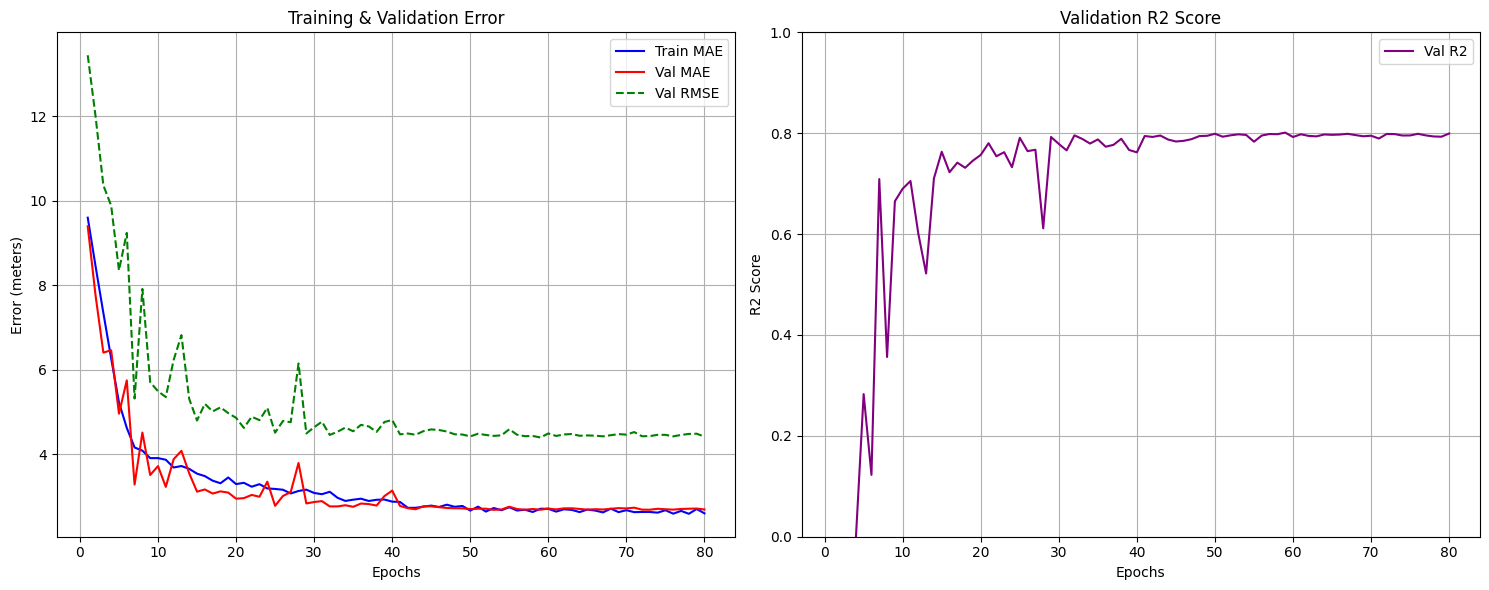

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_mae']) + 1)

    plt.figure(figsize=(15, 6))

    # Biểu đồ 1: MAE và RMSE (Sai số)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_mae'], 'b-', label='Train MAE')
    plt.plot(epochs, history['val_mae'], 'r-', label='Val MAE')
    plt.plot(epochs, history['val_rmse'], 'g--', label='Val RMSE')
    plt.title('Training & Validation Error')
    plt.xlabel('Epochs')
    plt.ylabel('Error (meters)')
    plt.legend()
    plt.grid(True)

    # Biểu đồ 2: R2 Score (Độ chính xác)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_r2'], 'purple', label='Val R2')
    plt.title('Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.ylim(0, 1) # Giới hạn trục Y từ 0 đến 1 (nếu R2 tốt)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ
plot_history(history)

#####Thực nghiệm 5: TĂNG NB_FILTER=[32, 64, 128, 256, 512] PATCH 512 TILE 256

In [ ]:

print("Bắt đầu huấn luyện...")
best_mae = float('inf')

for epoch in range(Config.EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0
    train_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")
    for x, y in pbar:
        x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
        x = torch.nan_to_num(x, nan=0.0)

        optimizer.zero_grad()
        pred = model(x)

        # Chỉ tính loss ở những pixel có dữ liệu (mask)
        mask = ~torch.isnan(y)
        if mask.sum() > 0:
            loss = torch.abs(pred[mask] - y[mask]).mean()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_count += 1
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        else:
            # Trường hợp batch toàn NaN (hiếm nhưng có thể xảy ra)
            optimizer.step()

    avg_train_mae = train_loss_sum / max(train_count, 1)

    # --- VALIDATE / TEST ---
    model.eval()
    val_preds_list = []
    val_targets_list = []

    with torch.no_grad():
        for x, y in val_loader: # Dùng val_loader hoặc test_loader tuỳ bạn
            x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
            x = torch.nan_to_num(x, nan=0.0)

            pred = model(x)

            # Chỉ lấy các pixel GEDI hợp lệ để tính metric
            mask = ~torch.isnan(y)
            if mask.sum() > 0:
                val_preds_list.append(pred[mask].cpu())
                val_targets_list.append(y[mask].cpu())

    # Tính toán Metrics
    val_mae, val_rmse, val_r2 = compute_global_metrics(val_preds_list, val_targets_list)

    # --- LOGGING ---
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Train MAE: {avg_train_mae:.4f} | Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f} | Val R2: {val_r2:.4f}")

    # Scheduler & Checkpoint
    scheduler.step(val_mae)

    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")

Bắt đầu huấn luyện...


Epoch 1/80: 100%|██████████| 300/300 [01:40<00:00,  2.98it/s, loss=10.5773]


Epoch 1/80 | Train MAE: 8.9035 | Val MAE: 7.7944 | Val RMSE: 12.3342 | Val R2: -0.5623
>>> Saved New Best Model (MAE: 7.7944)


Epoch 2/80: 100%|██████████| 300/300 [01:40<00:00,  2.99it/s, loss=5.4825] 


Epoch 2/80 | Train MAE: 7.4229 | Val MAE: 7.0739 | Val RMSE: 11.2251 | Val R2: -0.2940
>>> Saved New Best Model (MAE: 7.0739)


...

Epoch 78/80 | Train MAE: 2.4383 | Val MAE: 2.6953 | Val RMSE: 4.5032 | Val R2: 0.7917


Epoch 79/80: 100%|██████████| 300/300 [01:40<00:00,  2.98it/s, loss=1.8845]


Epoch 79/80 | Train MAE: 2.5002 | Val MAE: 2.6982 | Val RMSE: 4.5077 | Val R2: 0.7913


Epoch 80/80: 100%|██████████| 300/300 [01:40<00:00,  2.99it/s, loss=3.3757]


Epoch 80/80 | Train MAE: 2.4070 | Val MAE: 2.6972 | Val RMSE: 4.5018 | Val R2: 0.7919


In [ ]:
# MODEL VỚI ĐIỀU KIỆN 1024
# --- 1. KHỞI TẠO CÁC LIST ĐỂ LƯU LỊCH SỬ (THÊM ĐOẠN NÀY) ---
history = {
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

print("Bắt đầu huấn luyện...")
best_mae = float('inf')

for epoch in range(Config.EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0
    train_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")
    for x, y in pbar:
        x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
        x = torch.nan_to_num(x, nan=0.0)

        optimizer.zero_grad()
        pred = model(x)

        mask = ~torch.isnan(y)
        if mask.sum() > 0:
            loss = torch.abs(pred[mask] - y[mask]).mean()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_count += 1
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        else:
            optimizer.step()

    avg_train_mae = train_loss_sum / max(train_count, 1)

    # --- VALIDATE / TEST ---
    model.eval()
    val_preds_list = []
    val_targets_list = []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
            x = torch.nan_to_num(x, nan=0.0)

            pred = model(x)

            mask = ~torch.isnan(y)
            if mask.sum() > 0:
                val_preds_list.append(pred[mask].cpu())
                val_targets_list.append(y[mask].cpu())

    # Tính toán Metrics
    val_mae, val_rmse, val_r2 = compute_global_metrics(val_preds_list, val_targets_list)

    # --- 2. LƯU KẾT QUẢ VÀO HISTORY (THÊM ĐOẠN NÀY) ---
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    # --- LOGGING ---
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Train MAE: {avg_train_mae:.4f} | Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f} | Val R2: {val_r2:.4f}")

    # Scheduler & Checkpoint
    scheduler.step(val_mae)

    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f">>> Saved New Best Model (MAE: {best_mae:.4f})")

Bắt đầu huấn luyện...


Epoch 1/200: 100%|██████████| 75/75 [00:57<00:00,  1.31it/s, loss=7.8169]


Epoch 1/200 | Train MAE: 9.5905 | Val MAE: 8.8864 | Val RMSE: 13.2617 | Val R2: -0.8061
>>> Saved New Best Model (MAE: 8.8864)


Epoch 2/200: 100%|██████████| 75/75 [00:57<00:00,  1.31it/s, loss=5.6508]


Epoch 2/200 | Train MAE: 8.6989 | Val MAE: 8.3770 | Val RMSE: 12.7624 | Val R2: -0.6727
>>> Saved New Best Model (MAE: 8.3770)


...

Epoch 198/200 | Train MAE: 2.7677 | Val MAE: 2.6736 | Val RMSE: 4.4315 | Val R2: 0.7983


Epoch 199/200: 100%|██████████| 75/75 [00:57<00:00,  1.31it/s, loss=3.0328]


Epoch 199/200 | Train MAE: 2.8073 | Val MAE: 2.6907 | Val RMSE: 4.4645 | Val R2: 0.7953


Epoch 200/200: 100%|██████████| 75/75 [00:57<00:00,  1.31it/s, loss=2.4214]


Epoch 200/200 | Train MAE: 2.7448 | Val MAE: 2.6733 | Val RMSE: 4.4408 | Val R2: 0.7975


## LOAD BEST MODEL && VISUALIZE RESULT

In [ ]:
# ======================
# LOAD BEST MODEL
# ======================
model.load_state_dict(torch.load(Config.MODEL_SAVE_PATH, map_location=Config.DEVICE))
model.eval()

print("Loaded best model for testing")
test_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False
)

# ======================
# TEST INFERENCE
# ======================
test_preds = []
test_targets = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(Config.DEVICE)
        y = y.to(Config.DEVICE)

        # xử lý NaN input
        x = torch.nan_to_num(x, nan=0.0)

        pred = model(x)

        # mask NaN target
        mask = ~torch.isnan(y)
        if mask.sum() > 0:
            test_preds.append(pred[mask].cpu().numpy())
            test_targets.append(y[mask].cpu().numpy())
y_pred = np.concatenate(test_preds)
y_true = np.concatenate(test_targets)

print("Test samples:", y_true.shape[0])


✅ Loaded best model for testing


Testing: 100%|██████████| 136/136 [00:01<00:00, 121.37it/s]

Test samples: 16802


✅ Loaded best model. Running inference on validation set...


Testing:   0%|          | 0/9 [00:00<?, ?it/s]

Test samples collected: 16802


/tmp/ipython-input-4157173481.py:135: UserWarning: Glyph 7919 (\N{LATIN SMALL LETTER U WITH HORN AND TILDE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4157173481.py:135: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4157173481.py:135: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7919 (\N{LATIN SMALL LETTER U WITH HORN AND TILDE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/pyth

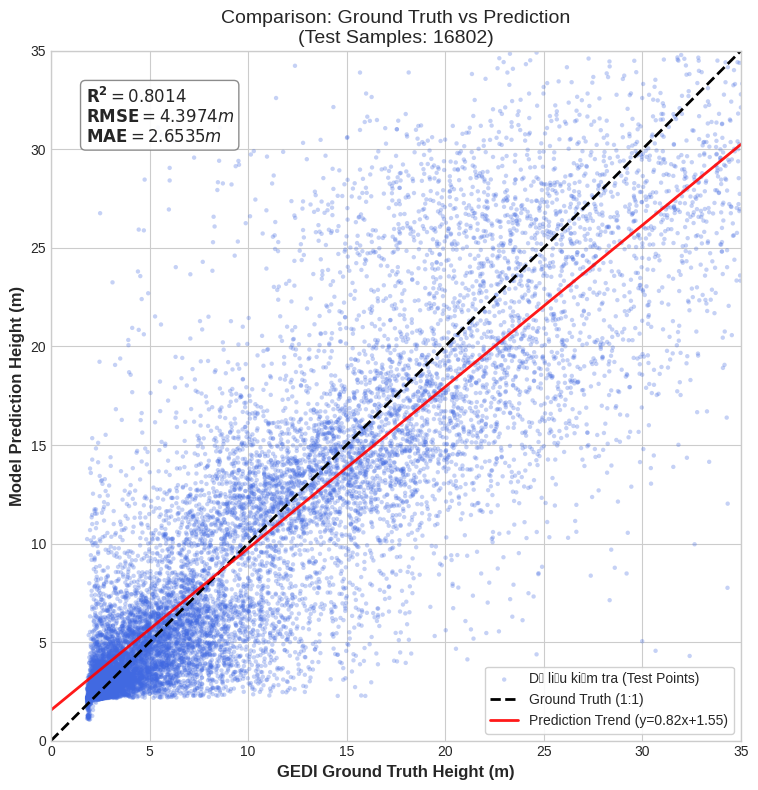

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# --- 1. Tính toán các chỉ số (Metrics) ---
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

# --- 3. Vẽ biểu đồ Scatter (Điểm dữ liệu) ---

scatter = ax.scatter(y_true, y_pred,
                     s=10,
                     c='royalblue',
                     alpha=0.4,
                     edgecolors='none',
                     label='Dữ liệu kiểm tra (Test Points)')

# --- 4. Xác định giới hạn trục  ---
# Tìm min/max chung để set trục
data_min = min(y_true.min(), y_pred.min())
data_max = max(y_true.max(), y_pred.max())
buffer = (data_max - data_min) * 0.05 # Thêm 5% lề
limit_range = [data_min - buffer, data_max + buffer]

# --- 5. Vẽ đường GROUND TRUTH (Quan trọng) ---
ax.plot(limit_range, limit_range,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Ground Truth (Đường chuẩn 1:1)')

# --- 6. (Tùy chọn) Vẽ đường hồi quy tuyến tính của mô hình ---
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true, y_pred)
line_x = np.array(limit_range)
line_y = slope * line_x + intercept
ax.plot(line_x, line_y,
        color='red',
        linestyle='-',
        linewidth=1.5,
        alpha=0.8,
        label=f'Đường xu hướng dự đoán (y={slope:.2f}x+{intercept:.2f})')

# --- 7. Chú thích ---
ax.set_xlim(limit_range)
ax.set_ylim(limit_range)
ax.set_aspect('equal', adjustable='box') # Bắt buộc hình vuông

ax.set_xlabel("GEDI Ground Truth Height (m)", fontsize=12, fontweight='bold')
ax.set_ylabel("Model Prediction Height (m)", fontsize=12, fontweight='bold')
ax.set_title(f"Comparison: Ground Truth vs Prediction\n(Test Samples: {len(y_true)})", fontsize=14)

textstr = '\n'.join((
    f'$\mathbf{{R^2}} = {r2:.4f}$',
    f'$\mathbf{{RMSE}} = {rmse:.4f}m$',
    f'$\mathbf{{MAE}} = {mae:.4f}m$'
    ))

props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.legend(loc='lower right', frameon=True, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.show()

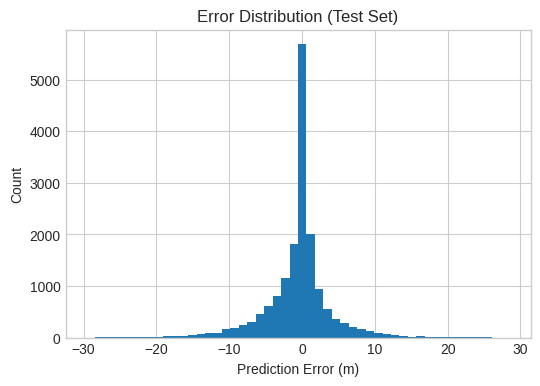

In [ ]:
errors = y_pred - y_true

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error (m)")
plt.ylabel("Count")
plt.title("Error Distribution (Test Set)")
plt.show()


🔄 Đang tải model...
Đã load thành công model: unetpp_best_model_14band.pth
👀 Đang visualize với kênh: Red=6, Green=5, Blue=4...


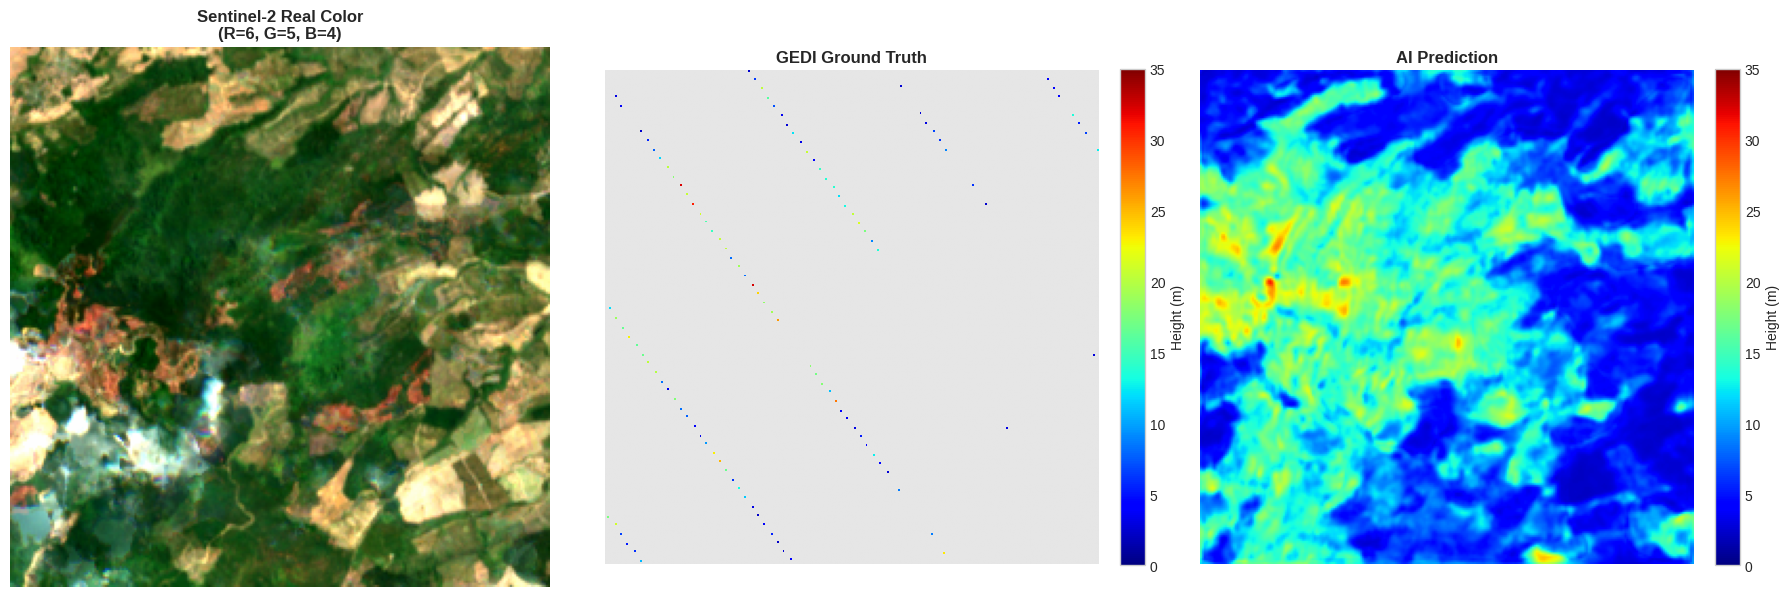

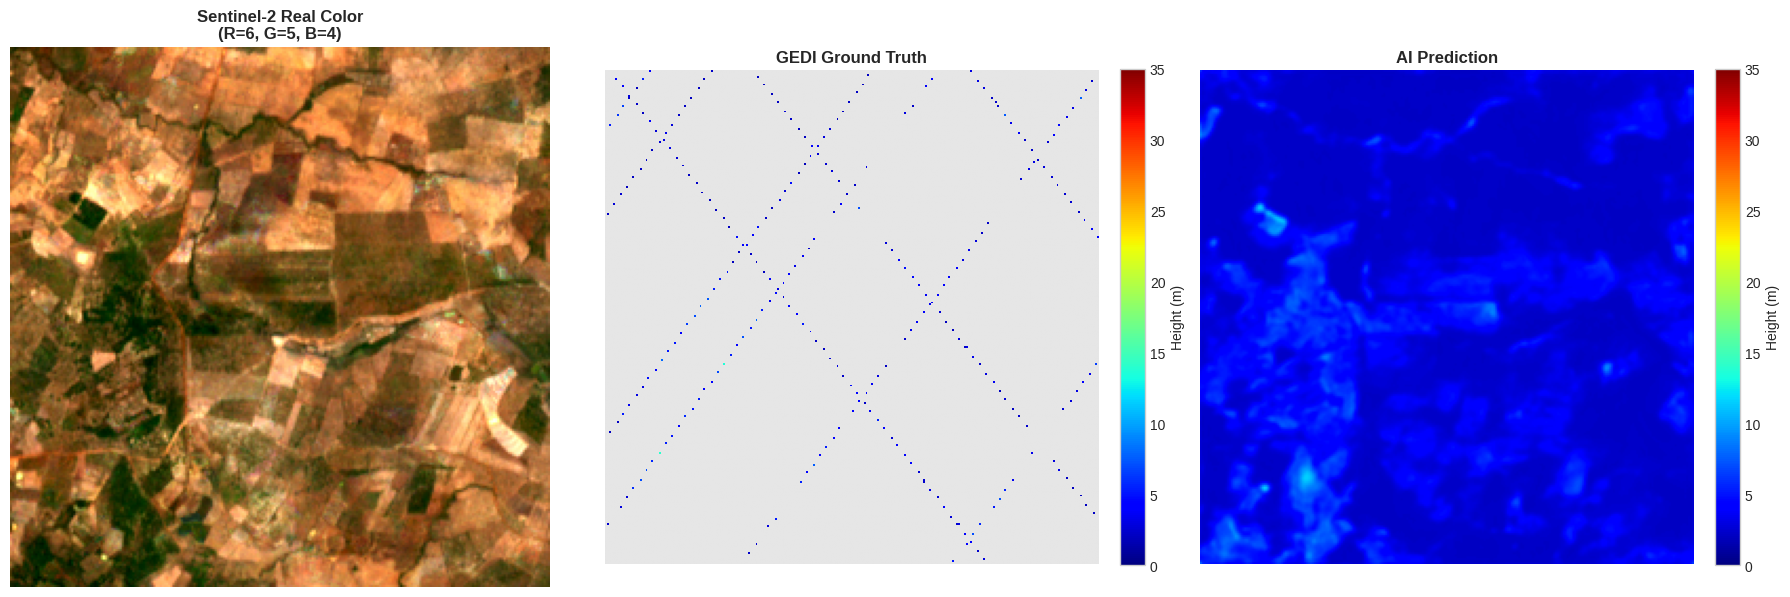

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
import os

# ==========================================
# 1. CẤU HÌNH & LOAD MODEL
# ==========================================

R_IDX = 6
G_IDX = 5
B_IDX = 4

def load_trained_model():
    model = UNetPlusPlus(in_channels=14, out_channels=1).to(Config.DEVICE)


    if os.path.exists(Config.MODEL_SAVE_PATH):
        try:
            state_dict = torch.load(Config.MODEL_SAVE_PATH, map_location=Config.DEVICE)
            new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

            model.load_state_dict(new_state_dict)
            print(f"Đã load thành công model: {Config.MODEL_SAVE_PATH}")
        except Exception as e:
            print(f"Lỗi khi load file weight: {e}")
            print("Đang dùng weight ngẫu nhiên (Kết quả sẽ sai!)")
    else:
        print(f"Không tìm thấy file {Config.MODEL_SAVE_PATH}. Đang dùng weight khởi tạo ngẫu nhiên.")

    model.eval()
    return model

# ==========================================
# 2. HÀM VISUALIZE (RGB CUSTOM BAND)
# ==========================================
def visualize_custom_bands(model, dataset, num_samples=2):
    print(f"Đang visualize với kênh: Red={R_IDX}, Green={G_IDX}, Blue={B_IDX}...")

    total = len(dataset)
    indices = random.sample(range(total), min(num_samples, total))

    for i, idx in enumerate(indices):
        sample = dataset[idx]
        if len(sample) == 3:
            img_tensor, label_tensor, mask_tensor = sample
        else:
            img_tensor, label_tensor = sample

        # --- CHẠY DỰ ĐOÁN ---
        with torch.no_grad():
            input_batch = img_tensor.unsqueeze(0).to(Config.DEVICE)
            input_batch = torch.nan_to_num(input_batch, nan=0.0)
            pred_tensor = model(input_batch)

        # --- XỬ LÝ ẢNH SENTINEL (RGB) ---
        try:
            rgb_img = img_tensor[[R_IDX, G_IDX, B_IDX], :, :].permute(1, 2, 0).cpu().numpy()

            # Kỹ thuật Percentile Stretching (2% - 98%) để cân bằng màu
            # Giúp ảnh không bị tối đen hoặc trắng xóa
            mask_valid = rgb_img > 0
            if mask_valid.sum() > 0:
                p2, p98 = np.percentile(rgb_img[mask_valid], (2, 98))
                rgb_img = np.clip(rgb_img, p2, p98)
                rgb_img = (rgb_img - p2) / (p98 - p2 + 1e-6)

        except Exception as e:
            print(f"Lỗi xử lý ảnh RGB: {e}. Index có thể vượt quá số kênh input.")
            rgb_img = np.zeros((256, 256, 3))

        # --- XỬ LÝ GEDI & KẾT QUẢ ---
        gt = label_tensor[0].cpu().numpy()
        gt_masked = np.ma.masked_where(gt <= 0, gt)

        pred = pred_tensor[0, 0].cpu().numpy()
        pred = np.maximum(pred, 0)

        # --- VẼ HÌNH ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Cột 1: Sentinel-2 Real Color
        axes[0].imshow(rgb_img)
        axes[0].set_title(f"Sentinel-2 Real Color\n(R={R_IDX}, G={G_IDX}, B={B_IDX})", fontweight='bold')
        axes[0].axis('off')

        # Cột 2: GEDI Ground Truth
        axes[1].imshow(np.ones_like(gt)*0.9, cmap='gray', vmin=0, vmax=1) # Nền xám
        im2 = axes[1].imshow(gt_masked, cmap='jet', vmin=0, vmax=35, interpolation='nearest')
        axes[1].set_title("GEDI Ground Truth", fontweight='bold')
        axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Height (m)')

        # Cột 3: AI Prediction
        im3 = axes[2].imshow(pred, cmap='jet', vmin=0, vmax=35)
        axes[2].set_title("AI Prediction", fontweight='bold')
        axes[2].axis('off')
        plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label='Height (m)')

        plt.tight_layout()
        plt.show()

# ==========================================
# 3. RUN
# ==========================================
model = load_trained_model()

visualize_custom_bands(model, train_ds, num_samples=2)
